In [1]:
using Pkg
Pkg.activate("../OldEnvironment")

  Activating project at `~/PhD/GaussianProcessNode/OldEnvironment`


In [ ]:
using ApproximateGPs
using Distributions, LinearAlgebra, StatsFuns
using PDMats: PDMat
using IterTools: ncycle
using Flux
using Plots
using JLD, MAT 
using CSV, DataFrames

In [43]:
#load data 
data = CSV.read("../data/co2data.csv", DataFrame);
X_data = data[:,4];
y_data = data[:,5];
N_data = 562;
xtrain, ytrain = X_data[1:N_data], y_data[1:N_data]; #from 1958 to 2005
xtest, ytest = X_data[N_data+1:end], y_data[N_data+1:end];
data_training = (xtrain, ytrain);
M = 250; #number of inducing points 
N = length(ytrain);

Xu = collect(range(1958,2005;length=M));

In [6]:
# standardized mean squared error (for regression)
function SMSE(y_true, y_approx)
    N = length(y_true)
    mse = norm(y_true - y_approx)^2 / N 
    return mse / var(y_true)
end


SMSE (generic function with 1 method)

In [44]:
function make_kernel(θ)
    k1 = StatsFuns.softplus(θ[1])*with_lengthscale(SEKernel(), StatsFuns.softplus(θ[2])) #long
    k2 = with_lengthscale(PeriodicKernel(), StatsFuns.softplus(θ[3])) #period
    k3 = StatsFuns.softplus(θ[4])*with_lengthscale(SEKernel(),StatsFuns.softplus(θ[5]))
    k4 = StatsFuns.softplus(θ[6])*with_lengthscale(RationalQuadraticKernel(α=StatsFuns.softplus(θ[7])),StatsFuns.softplus(θ[8]))
    k5 = StatsFuns.softplus(θ[9])*with_lengthscale(SEKernel(),StatsFuns.softplus(θ[10])) #short 
    return  k1 + k2 * k3  + k4 + k5
end
θ_init = StatsFuns.invsoftplus.([1., 1., 1.4, 2.4, 1., 1., 0.01, 1., 1.16, 1.11]);

In [45]:
struct SVGPModel
    k  :: Vector{Float64}     # kernel parameters
    m  :: Vector{Float64}   # variational mean
    A  :: Matrix{Float64}     # square-root of variational covariance
end

Flux.@functor SVGPModel (k, m, A);

In [46]:
lik_noise = 0.1
jitter = 1e-5;
function prior(m::SVGPModel)
    kernel = make_kernel(m.k)
    return GP(kernel)
end
function make_approx(m::SVGPModel, prior)
    # Efficiently constructs S as A*Aᵀ
    S = PDMat(Cholesky(LowerTriangular(m.A)))
    q = MvNormal(m.m, S)
    fz = prior(Xu, jitter)
    return SparseVariationalApproximation(fz, q)
end;
function model_posterior(m::SVGPModel)
    svgp = make_approx(m, prior(m))
    return posterior(svgp)
end;

function (m::SVGPModel)(x)
    post = model_posterior(m)
    return post(x)
end;

function loss(m::SVGPModel, x, y; num_data=length(ytrain))
    f = prior(m)
    fx = f(x, lik_noise)
    svgp = make_approx(m, f)
    return -elbo(svgp, fx, y; num_data)
end;

In [47]:
m_init = zeros(M)
A_init = Matrix{Float64}(I, M, M)

model = SVGPModel(θ_init, m_init, A_init);
opt = AdaMax()  # Define the optimiser
params_toy = Flux.params(model);  # Extract the model parameters

In [48]:
data_loader = Flux.DataLoader((xtrain, ytrain);batchsize=N)
loss_val = []
callback = function ()
    append!(loss_val,loss(model,xtrain,ytrain))
end
Flux.train!(
    (x, y) -> loss(model, x, y; num_data=N),
    params_toy,
    ncycle(data_loader, 20000), 
    opt;
    cb = callback
);

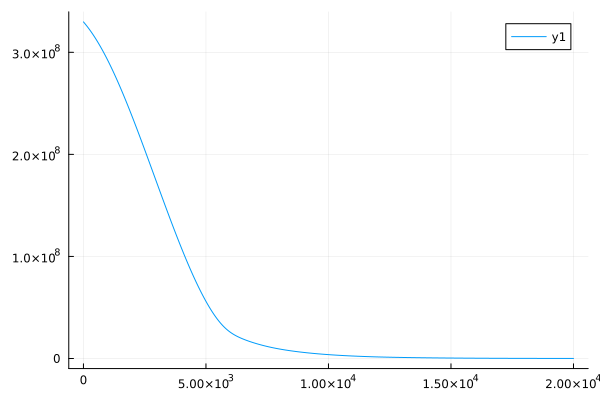

In [54]:
plot(loss_val)

In [55]:
post = model_posterior(model)
my_predict = post(X_data);

In [56]:
predict_mean, predict_var = mean(my_predict), var(my_predict);

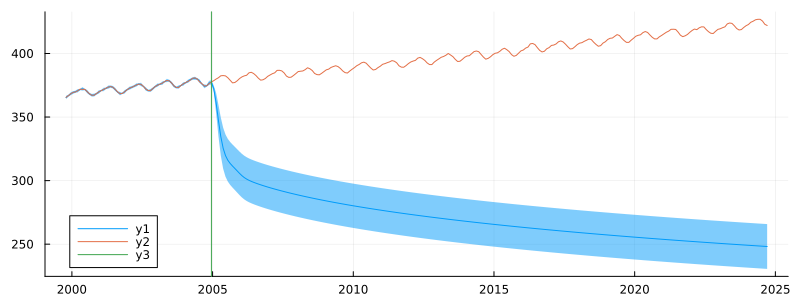

In [59]:
plot(X_data[500:end], predict_mean[500:end],ribbon = 2 .* sqrt.(predict_var[500:end]), size=(800,300))
plot!(X_data[500:end], y_data[500:end])
vline!([xtrain[end]])

In [60]:
fieldnames(typeof(model))

(:k, :m, :A)

In [63]:
StatsFuns.softplus.(model.k)

10-element Vector{Float64}:
 20.508130431014294
  0.18128492200368124
  0.9114799949826238
 22.3137494989769
  0.4970344902996693
 20.127239968658497
  0.09342199107564005
  0.7403619725949605
 20.741356930813183
  0.18166780438761362